In [4]:
import os

base_path = "../data/abnormal"

classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
print("num classes:" ,len(classes))
print("classes:", classes)

num classes: 14
classes: ['Bronchral', 'Crackles', 'OtherSounds', 'Creptation', 'pleural effusion', 'aortic', 'Wheezing', 'Asthma', 'pleural rub', 'wheezing- copd', 'rhonching', 'pneumonia3', 'pneumonia patient', 'COPD']


In [5]:
import os
import pandas as pd
import numpy as np
import librosa

base_path = "../data/abnormal"

records = []

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        for root, _, files in os.walk(cls_path):
            for file in files:
                if file.lower().endswith(".wav"):
                    path = os.path.join(root, file)
                    y, sr = librosa.load(path, sr=None)
                    records.append({
                        "class": cls,
                        "duration": len(y)/sr,
                        "sampling_rate": sr,
                        "rms": np.mean(librosa.feature.rms(y=y)),
                        "zcr": np.mean(librosa.feature.zero_crossing_rate(y))
                    })

df = pd.DataFrame(records)

print(df.shape)
print(df["class"].value_counts())

(732, 5)
class
Creptation           215
Wheezing             173
OtherSounds           64
pneumonia patient     64
rhonching             52
pneumonia3            50
COPD                  39
Crackles              16
Bronchral             14
pleural effusion      13
wheezing- copd        11
Asthma                 9
pleural rub            7
aortic                 5
Name: count, dtype: int64


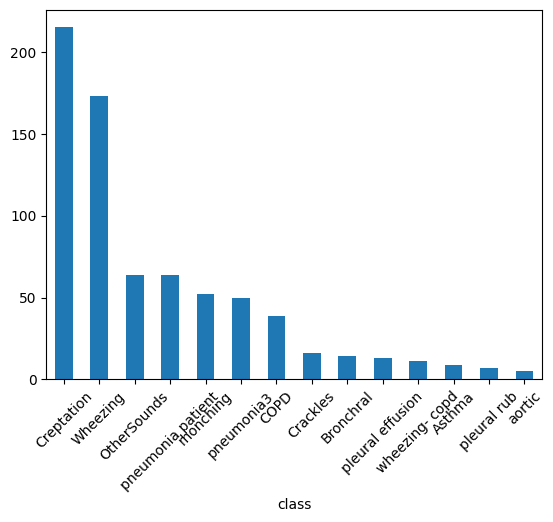

In [6]:
import matplotlib.pyplot as plt

plt.figure()
df["class"].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.show()

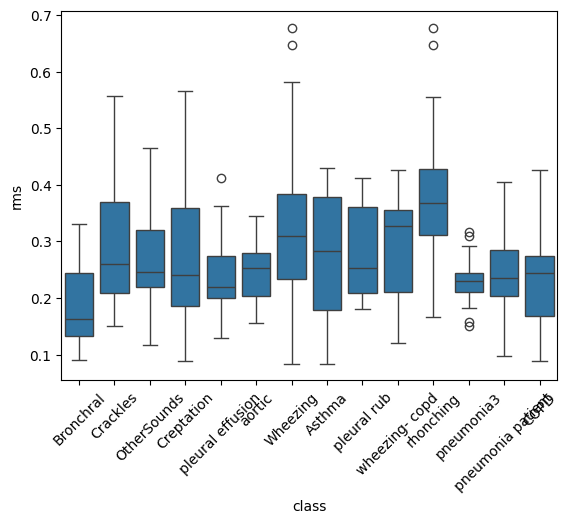

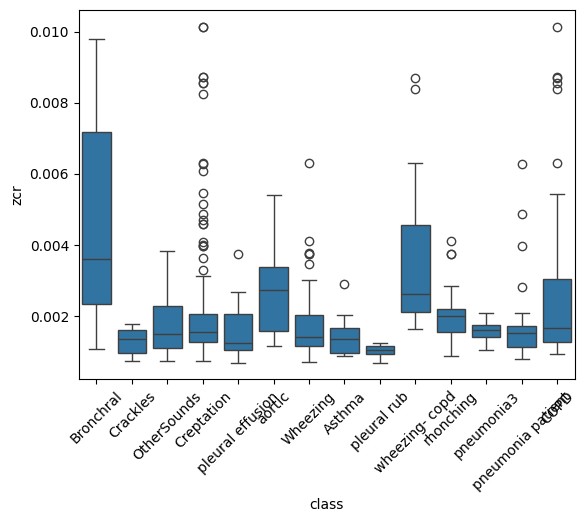

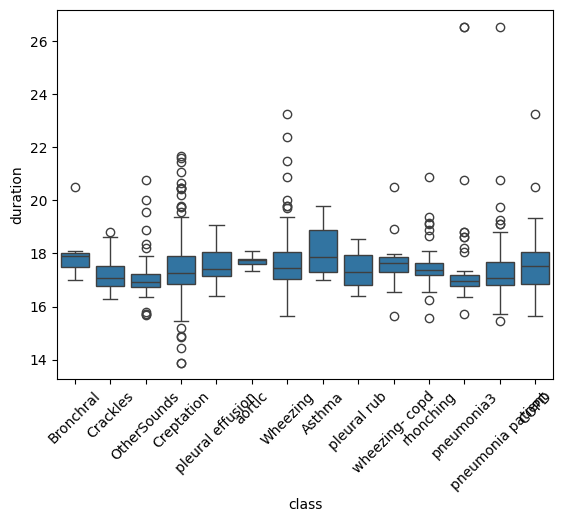

In [7]:
import seaborn as sns

plt.figure()
sns.boxplot(x="class", y="rms", data=df)
plt.xticks(rotation=45)

plt.figure()
sns.boxplot(x="class", y="zcr", data=df)
plt.xticks(rotation=45)

plt.figure()
sns.boxplot(x="class", y="duration", data=df)
plt.xticks(rotation=45)

plt.show()